# Symulator tomografu

Kod testowy

Test wzorów

In [1]:
# Importy

import utils
import filter
import save_dicom
import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import resize
import imageio.v2 as iio
import datetime
import os

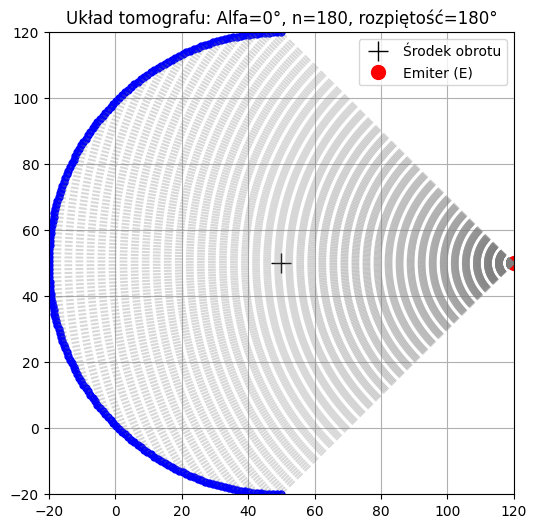

In [2]:
# --- PARAMETRY TESTOWE ---
wymiar_obrazka = 100 # Zakładamy, że nasz obrazek będzie miał 100x100 pikseli
srodek = wymiar_obrazka / 2
# Promień musi być na tyle duży, żeby czujniki "latały" dookoła obrazka (poza nim)
promien = wymiar_obrazka * 0.7 

kat_alfa = 0        # Zaczynamy od kąta 0 stopni
liczba_detektorow = 180  
rozpietosc = 180 

emiter, detektory = utils.wyznacz_pozycje_czujnikow(kat_alfa, liczba_detektorow, rozpietosc, promien, srodek, srodek)

# --- RYSOWANIE WYNIKÓW ---
plt.figure(figsize=(6, 6))

# Rysujemy środek układu (środek naszego przyszłego obrazka)
plt.plot(srodek, srodek, 'k+', markersize=15, label="Środek obrotu")

# Rysujemy Emiter (jako czerwoną kropkę)
plt.plot(emiter[0], emiter[1], 'ro', markersize=10, label="Emiter (E)")

# Rysujemy Detektory (jako niebieskie kropki)
for d in detektory:
    plt.plot(d[0], d[1], 'bo', markersize=5)
    # Rysujemy też promienie (linie od emitera do detektorów)
    plt.plot([emiter[0], d[0]], [emiter[1], d[1]], 'gray', alpha=0.3, linestyle='--')

# Ograniczamy osie wykresu dla lepszej widoczności
plt.xlim(-20, wymiar_obrazka + 20)
plt.ylim(-20, wymiar_obrazka + 20)
plt.legend()
plt.title(f"Układ tomografu: Alfa={kat_alfa}°, n={liczba_detektorow}, rozpiętość={rozpietosc}°")
plt.grid(True)
plt.show()

Chyba działa

In [3]:
image = iio.imread('./tomograf-obrazy/CT_ScoutView.jpg', mode='L')  
image = resize(image, (100, 100))
wymiar_y, wymiar_x = image.shape

liczba_detektorow = 180 
liczba_skanow = 180      # Ile razy emiter "błyśnie" podczas obrotu
rozpietosc = 180         # Szerokość wachlarza w stopniach

sinogram_1 = utils.stworz_sinogram(wymiar_x, wymiar_y, liczba_detektorow, liczba_skanow, rozpietosc, image)

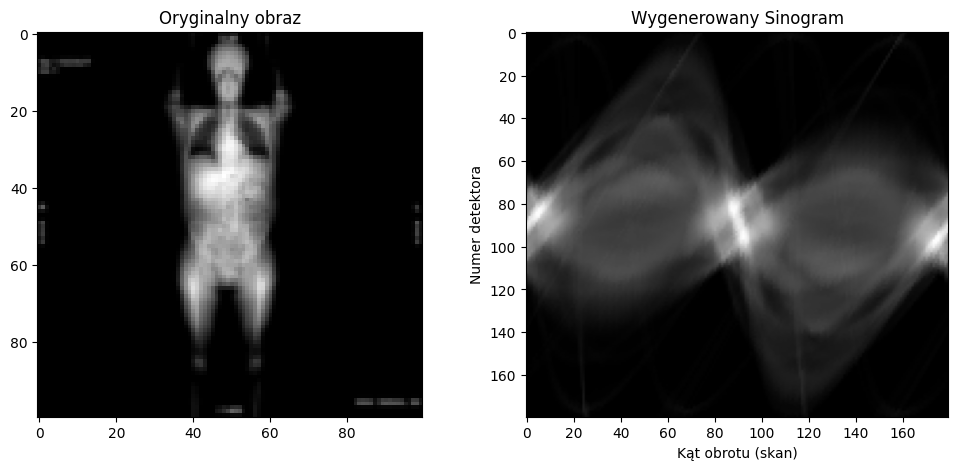

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(image, cmap='gray')
ax1.set_title("Oryginalny obraz")

ax2.imshow(sinogram_1, cmap='gray', aspect='auto')
ax2.set_title("Wygenerowany Sinogram")
ax2.set_xlabel("Kąt obrotu (skan)")
ax2.set_ylabel("Numer detektora")

plt.show()

Rekonstrukcja obrazu - odwrotna transformata Radona

In [5]:
rekonstrukcja_1 = utils.rekonstrukcja_obrazu(wymiar_x, wymiar_y, liczba_detektorow, liczba_skanow, rozpietosc, sinogram_1)

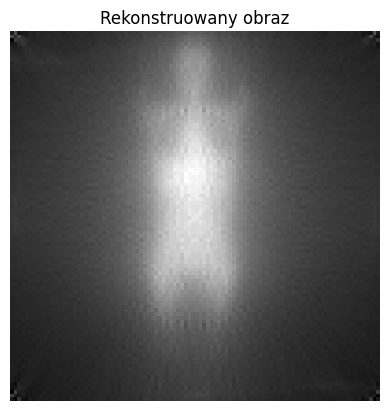

In [6]:
plt.imshow(rekonstrukcja_1, cmap='gray')
plt.title("Rekonstruowany obraz")
plt.axis('off')
plt.show()


Filtrowanie -> **Do poprawy bo na niektórych obrazach nie działa i dodać mse**

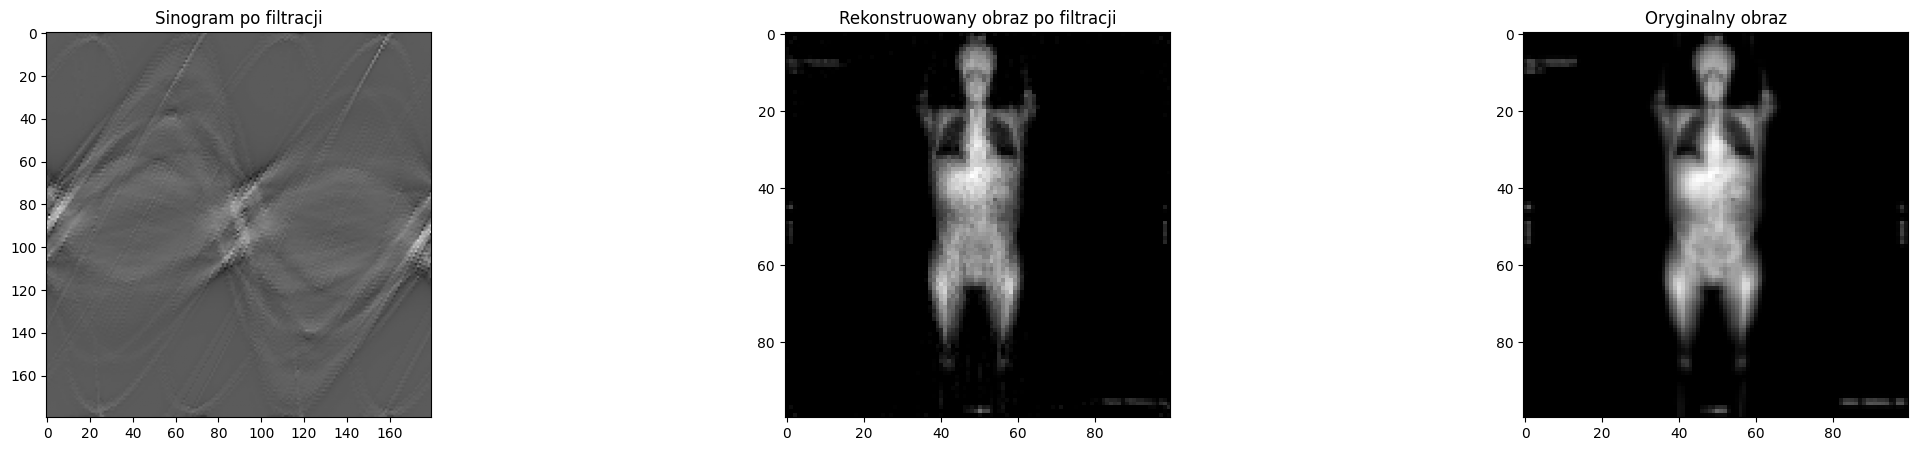

In [7]:
sinogram_filtrowany = filter.filtruj_sinogram(sinogram_1)
delta_alfa = 360 / liczba_skanow
srodek_x, srodek_y = wymiar_x / 2, wymiar_y / 2

rekonstruowany_obraz_filtrowany = utils.rekonstrukcja_obrazu(wymiar_x, wymiar_y, liczba_detektorow, liczba_skanow, rozpietosc, sinogram_filtrowany)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(27, 5))
ax1.imshow(sinogram_filtrowany, cmap='gray')
ax1.set_title("Sinogram po filtracji")
ax2.imshow(rekonstruowany_obraz_filtrowany, cmap='gray')
ax2.set_title("Rekonstruowany obraz po filtracji")
ax3.imshow(image, cmap='gray')
ax3.set_title("Oryginalny obraz")
plt.show()

Pokazanie obrazu w formacie DICOM - na razie wyłączone

In [8]:
dane_pacjenta = ("Jan", "Kowalski", "98051599415")
data_badania = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
nazwa_pliku = f"dicom/rekonstrukcja_{dane_pacjenta[0]}_{dane_pacjenta[1]}_{data_badania.replace(':', '-')}.dcm"
komentarz = "Rekonstrukcja tomograficzna z filtrowaniem"

# save_dicom.zapisz_dicom(rekonstruowany_obraz_filtrowany, nazwa_pliku, dane_pacjenta, data_badania, komentarz)

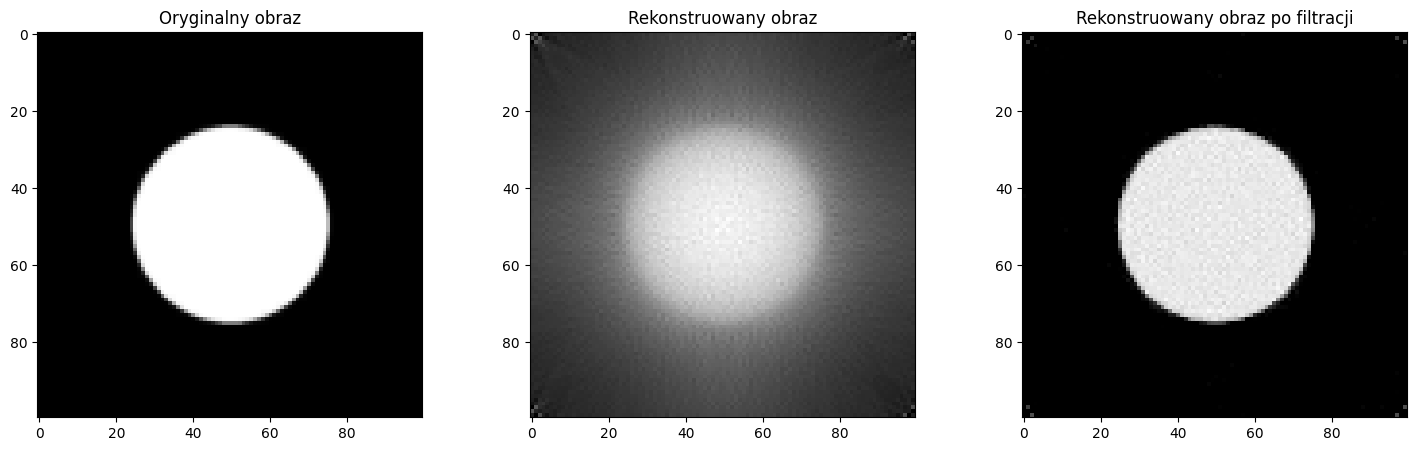

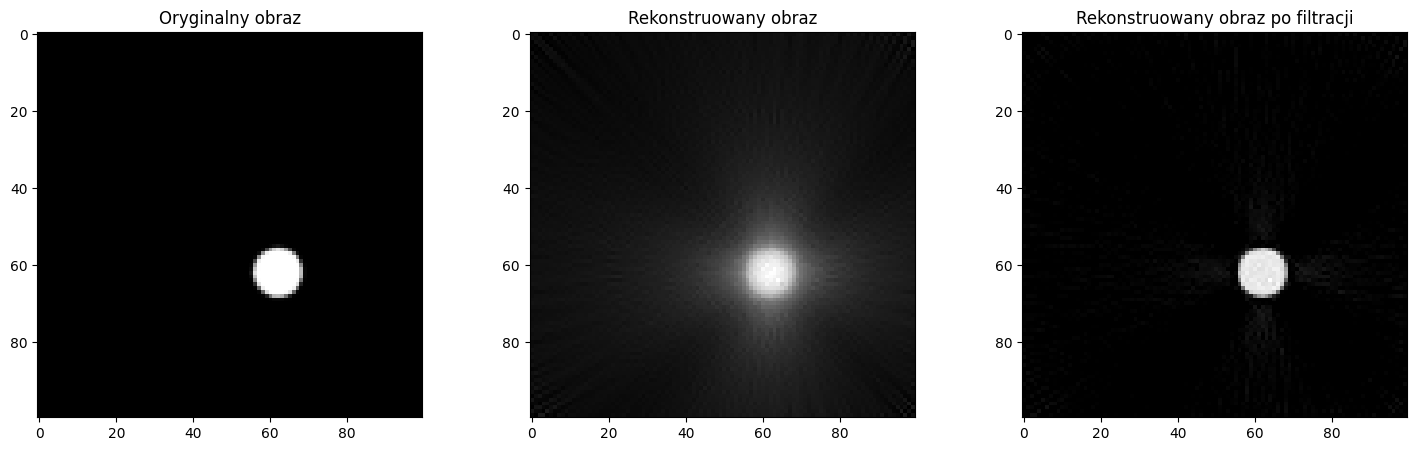

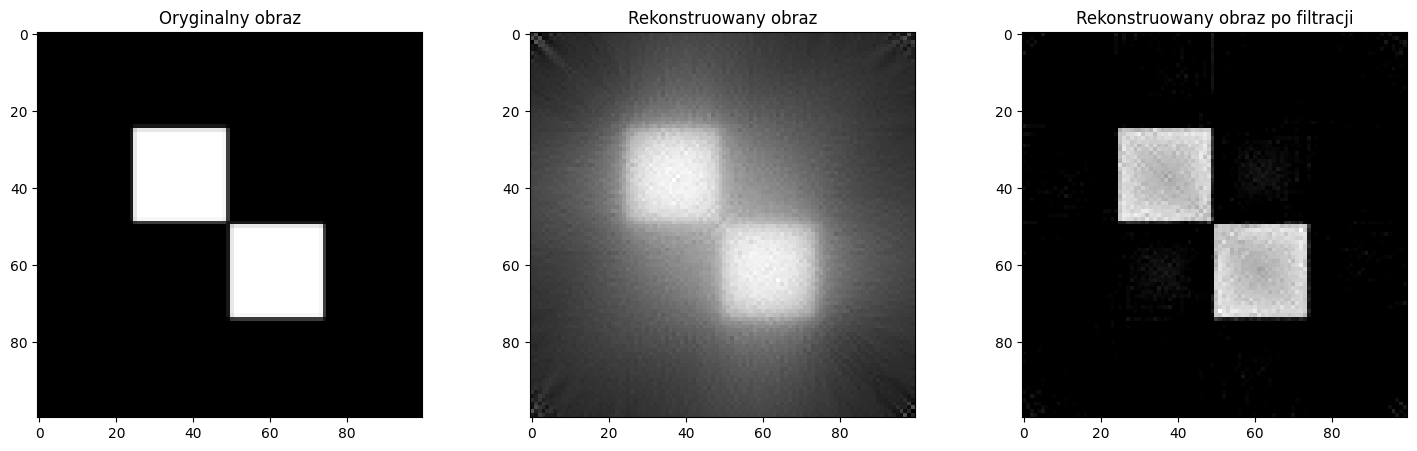

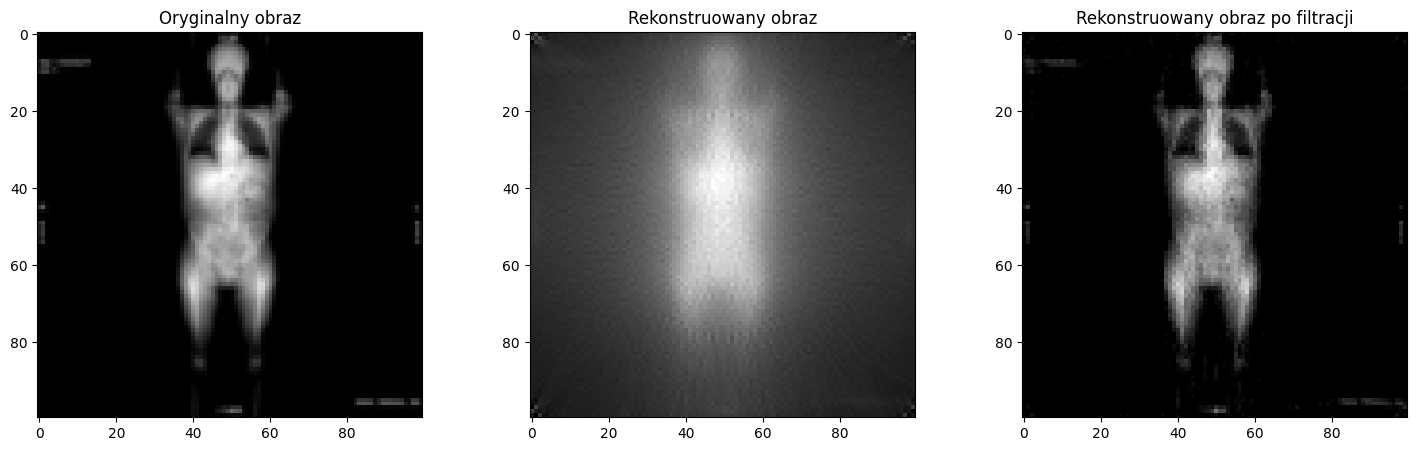

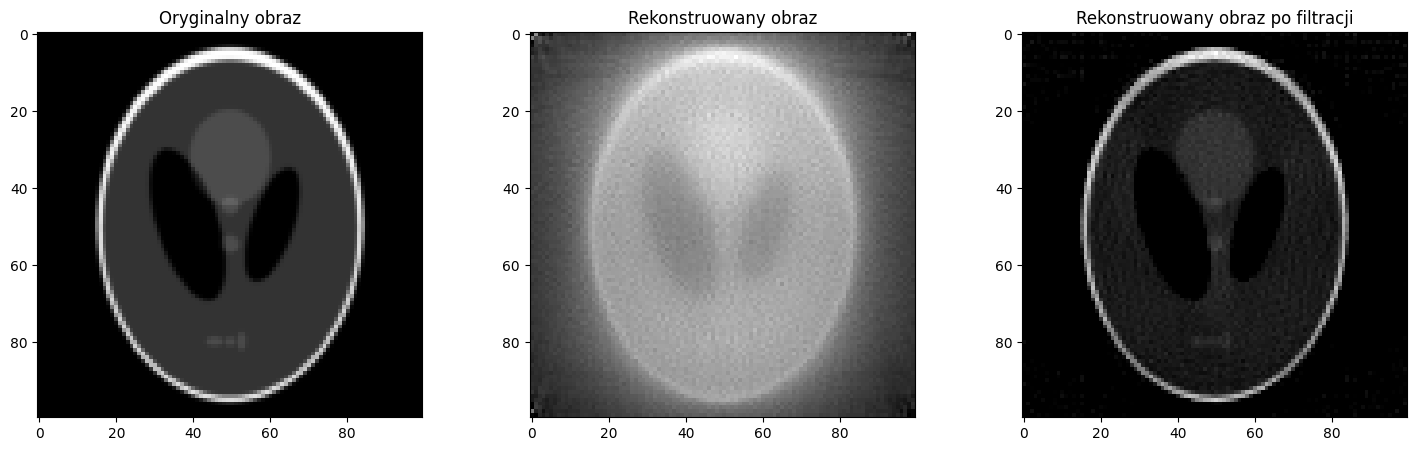

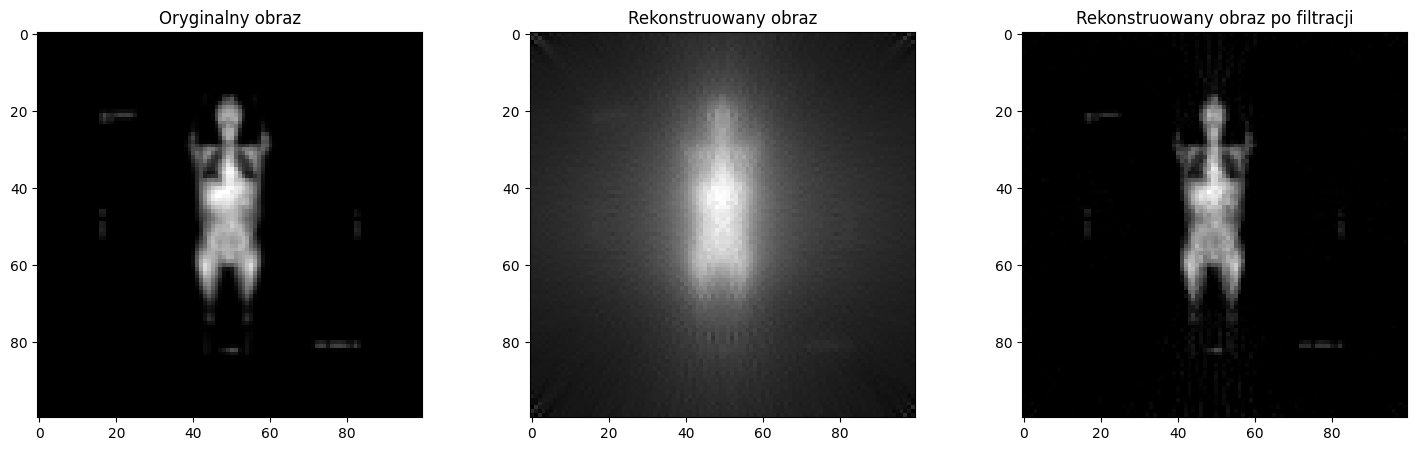

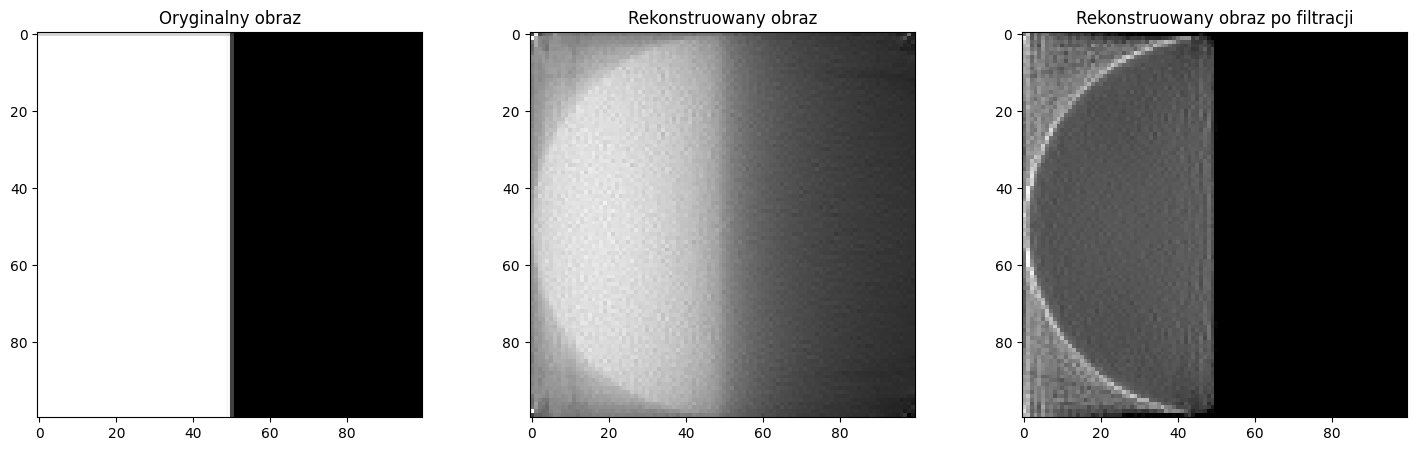

In [10]:
files = [f for f in os.listdir('./tomograf-obrazy/') if f.endswith('.jpg')]

for f in files:
    image = iio.imread(f'./tomograf-obrazy/{f}', mode='L')  
    image = resize(image, (100, 100))
    wymiar_y, wymiar_x = image.shape

    liczba_detektorow = 180 
    liczba_skanow = 180      
    rozpietosc = 180         

    sinogram_1 = utils.stworz_sinogram(wymiar_x, wymiar_y, liczba_detektorow, liczba_skanow, rozpietosc, image)
    rekonstrukcja_1 = utils.rekonstrukcja_obrazu(wymiar_x, wymiar_y, liczba_detektorow, liczba_skanow, rozpietosc, sinogram_1)
    rekonstrukcja_1_filtrowana = utils.rekonstrukcja_obrazu(wymiar_x, wymiar_y, liczba_detektorow, liczba_skanow, rozpietosc, filter.filtruj_sinogram(sinogram_1))

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    ax1.imshow(image, cmap='gray')
    ax1.set_title("Oryginalny obraz")
    ax2.imshow(rekonstrukcja_1, cmap='gray')
    ax2.set_title("Rekonstruowany obraz")
    ax3.imshow(rekonstrukcja_1_filtrowana, cmap='gray')
    ax3.set_title("Rekonstruowany obraz po filtracji")
    plt.show()